# Exploratory Data Analysis (EDA)
## Final Merged Dataset: 5Essentials + 311 + CPS + ACS

**Author:** An Nisa Astuti & Yi Wang  
**Dataset:** 77 Chicago community areas × 39 variables

**AI Statement:** We used AI to adjust visualization parameters such as figure sizing, color scales, and annotation formatting.

### Research Question
How do differences in city service responsiveness and neighborhood conditions relate to school outcomes across Chicago neighborhoods?

### Hypothesis
Neighborhoods with slower 311 response times will exhibit worse school climate and lower student attendance.

## Setup

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# statsmodels
import statsmodels.api as sm                    # core statsmodels library (no formula syntax)
from statsmodels.formula.api import ols as sfm  # ols reg using formula syntax 
from statsmodels.formula.api import logit       # logistic reg using formula syntax
import statsmodels.stats.api as sms             # t-test 

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

## 1. Load Data

In [61]:
df = pd.read_csv('final_merged_5e_311_cps_acs.csv')

# Drop extreme outlier: EAST SIDE has sr_avg_median_ttc_hours ~6327h (next highest is ~869h)
df = df[df['sr_avg_median_ttc_hours'] < 1500].reset_index(drop=True)

print('DATASET OVERVIEW')
print(f'Shape: {df.shape[0]} community areas × {df.shape[1]} variables')
print(f'\nColumn types:')
print(df.dtypes.value_counts())
print(f'\nColumns:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2}. {col}')


DATASET OVERVIEW
Shape: 76 community areas × 39 variables

Column types:
float64    32
int64       6
str         1
Name: count, dtype: int64

Columns:
 1. community_area
 2. community_area_name
 3. n_schools_5e
 4. avg_leaders_score
 5. avg_teachers_score
 6. avg_families_score
 7. avg_environment_score
 8. avg_instruction_score
 9. sr_total_requests
10. sr_total_closed
11. sr_avg_share_closed
12. sr_avg_median_ttc_hours
13. sr_avg_p75_ttc_hours
14. sr_avg_pct_closed_24h
15. sr_avg_pct_closed_7d
16. sr_avg_pct_closed_30d
17. cps_n_schools
18. cps_student_attendance
19. cps_teacher_attendance
20. cps_mobility_rate
21. cps_graduation_rate
22. cps_college_enrollment
23. acs_total_population
24. acs_poverty_rate
25. acs_median_household_income_weighted
26. acs_unemployment_rate
27. acs_pct_less_than_hs
28. acs_pct_bachelor_plus
29. acs_snap_rate
30. acs_public_assist_rate
31. acs_rent_burden_30p_rate
32. acs_rent_burden_50p_rate
33. acs_crowding_rate
34. acs_pct_renter
35. acs_vacancy_rate

## 2. Missing Values Analysis

In [62]:
print('MISSING VALUES')

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print(missing_df)

MISSING VALUES
                       Missing Count  Missing %
cps_mobility_rate                 16       21.1
cps_graduation_rate               15       19.7
avg_environment_score              1        1.3
avg_instruction_score              1        1.3


## 3. Define Variable Groups

In [63]:
# Define variable groups for analysis
essentials = ['avg_leaders_score', 'avg_teachers_score', 'avg_families_score', 
              'avg_environment_score', 'avg_instruction_score']

sr_vars = ['sr_avg_median_ttc_hours', 'sr_avg_pct_closed_7d', 'sr_avg_pct_closed_24h']

cps_vars = ['cps_student_attendance', 'cps_mobility_rate', 'cps_graduation_rate']

acs_vars = ['acs_poverty_rate', 'acs_median_household_income_weighted', 
            'acs_unemployment_rate', 'acs_pct_bachelor_plus']

* sr_vars - IV: 311 responsiveness
* essentials - Mediator: School climate - 5essentials
* cps_vars - DV: Educational outcomes - CPS
* acs_vars - Controls: Neighborhood disadvantage - ACS data

## 4. Summary Statistics

In [64]:
def create_summary_with_category(df, vars_list, category_name):
    summary = df[vars_list].describe().round(2).T  # Transpose
    summary['Category'] = category_name
    summary = summary.reset_index().rename(columns={'index': 'Variable'})
    return summary

# Create summaries
summary_5e = create_summary_with_category(df, essentials, '5Essentials (School Climate)')
summary_311 = create_summary_with_category(df, sr_vars, '311 Service Responsiveness')
summary_cps = create_summary_with_category(df, cps_vars, 'CPS Educational Outcomes')
summary_acs = create_summary_with_category(df, acs_vars, 'ACS Neighborhood Disadvantage')

# Combine all
df_summary = pd.concat([summary_5e, summary_311, summary_cps, summary_acs], ignore_index=True)

# Reorder columns
df_summary = df_summary[['Category', 'Variable', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# Display
df_summary

,Category,Variable,count,mean,std,min,25%,50%,75%,max
0,5Essentials (School Climate),avg_leaders_score,76.0,52.82,6.06,41.17,49.46,51.84,55.46,79.88
1,5Essentials (School Climate),avg_teachers_score,76.0,51.67,5.92,36.83,47.80,50.97,53.77,76.29
2,5Essentials (School Climate),avg_families_score,76.0,53.73,7.73,41.47,47.45,52.74,58.65,79.38
3,5Essentials (School Climate),avg_environment_score,75.0,49.66,6.54,30.88,46.88,49.11,53.05,67.00
4,5Essentials (School Climate),avg_instruction_score,75.0,54.79,5.83,42.44,50.19,53.83,58.17,72.33
5,311 Service Responsiveness,sr_avg_median_ttc_hours,76.0,199.40,190.57,21.86,75.05,128.92,249.69,869.31
6,311 Service Responsiveness,sr_avg_pct_closed_7d,76.0,0.60,0.07,0.46,0.55,0.61,0.65,0.76
7,311 Service Responsiveness,sr_avg_pct_closed_24h,76.0,0.36,0.07,0.23,0.31,0.35,0.40,0.58
8,CPS Educational Outcomes,cps_student_attendance,76.0,91.37,1.17,88.36,90.50,91.35,92.28,93.84
9,CPS Educational Outcomes,cps_mobility_rate,60.0,78.08,12.14,42.73,71.52,79.88,85.33,96.57


## 5. Distribution Plots - 5Essentials (School Climate)

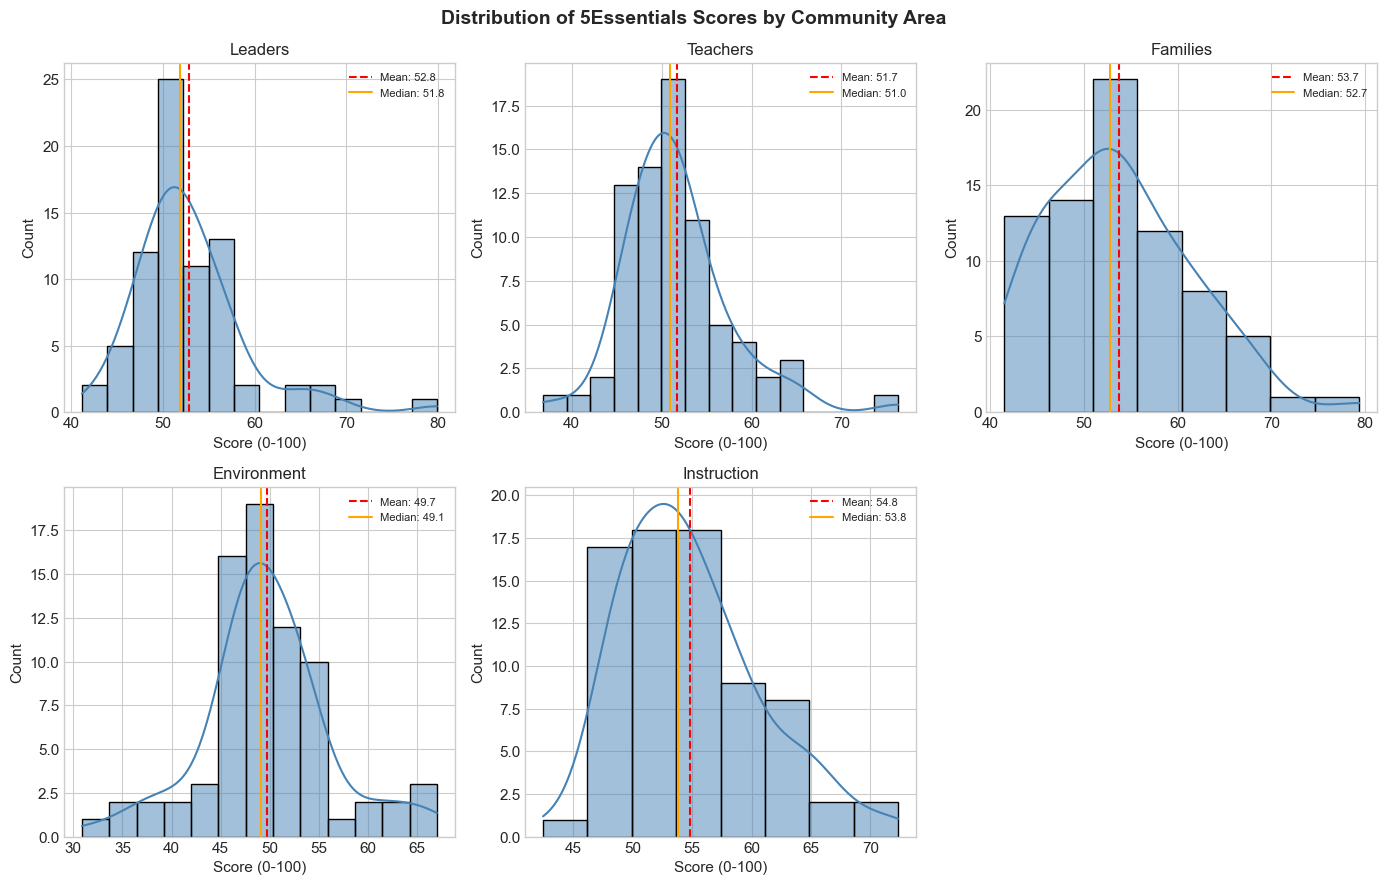

In [65]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(essentials):
    ax = axes[i]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='steelblue', edgecolor='black')
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle='-', label=f'Median: {df[col].median():.1f}')
    ax.set_title(col.replace('avg_', '').replace('_score', '').title(), fontsize=12)
    ax.set_xlabel('Score (0-100)')
    ax.legend(fontsize=8)

axes[5].axis('off')
plt.suptitle('Distribution of 5Essentials Scores by Community Area', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_02_5essentials_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Distribution Plots - 311 Responsiveness

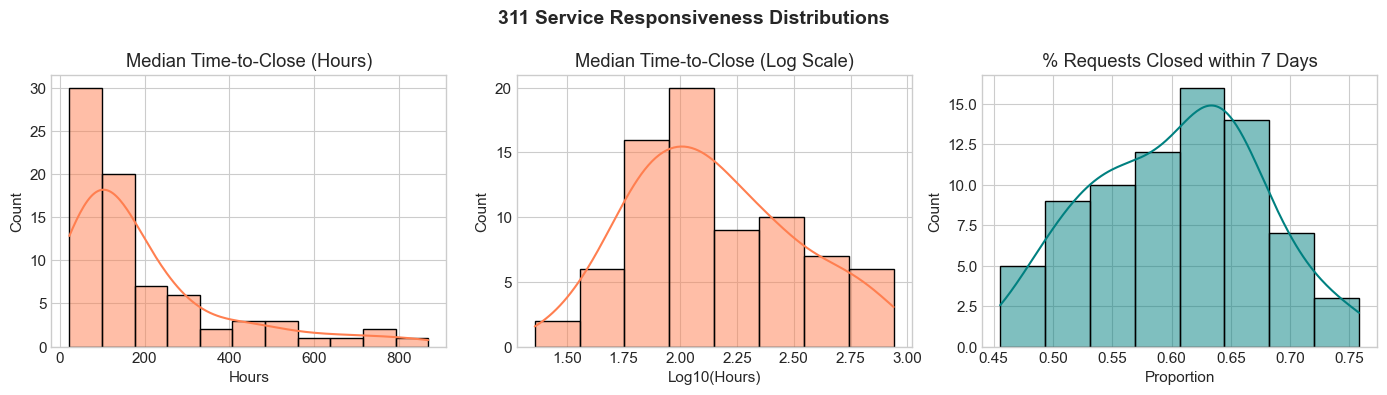

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Median time-to-close
ax1 = axes[0]
sns.histplot(df['sr_avg_median_ttc_hours'], kde=True, ax=ax1, color='coral', edgecolor='black')
ax1.set_xlabel('Hours')
ax1.set_title('Median Time-to-Close (Hours)')

# Log transform for skewed distribution
ax2 = axes[1]
log_ttc = np.log10(df['sr_avg_median_ttc_hours'] + 1)
sns.histplot(log_ttc, kde=True, ax=ax2, color='coral', edgecolor='black')
ax2.set_xlabel('Log10(Hours)')
ax2.set_title('Median Time-to-Close (Log Scale)')

# % Closed within 7 days
ax3 = axes[2]
sns.histplot(df['sr_avg_pct_closed_7d'], kde=True, ax=ax3, color='teal', edgecolor='black')
ax3.set_xlabel('Proportion')
ax3.set_title('% Requests Closed within 7 Days')

plt.suptitle('311 Service Responsiveness Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_311_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Distribution Plots - CPS Educational Outcomes

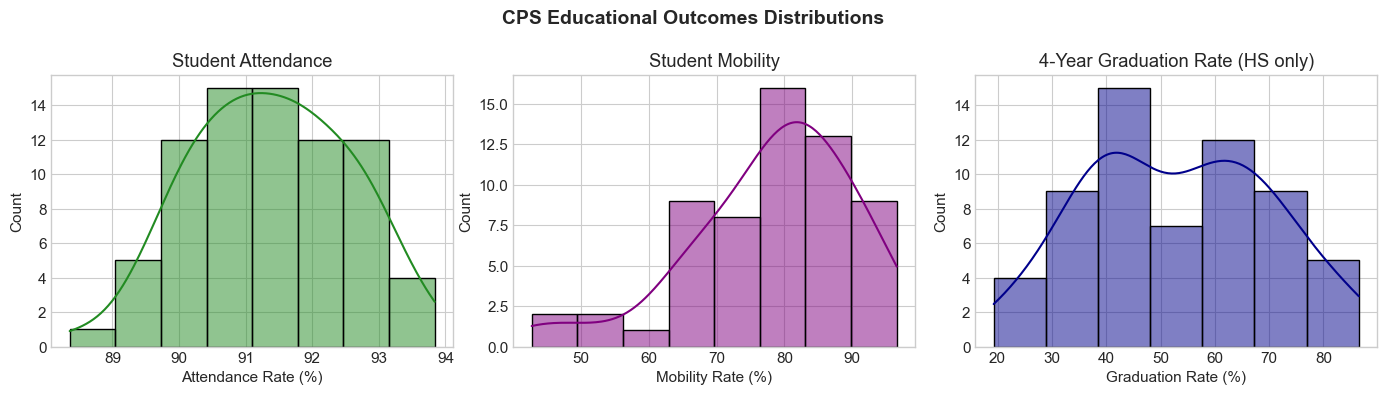

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax1 = axes[0]
sns.histplot(df['cps_student_attendance'].dropna(), kde=True, ax=ax1, color='forestgreen', edgecolor='black')
ax1.set_xlabel('Attendance Rate (%)')
ax1.set_title('Student Attendance')

ax2 = axes[1]
sns.histplot(df['cps_mobility_rate'].dropna(), kde=True, ax=ax2, color='purple', edgecolor='black')
ax2.set_xlabel('Mobility Rate (%)')
ax2.set_title('Student Mobility')

ax3 = axes[2]
sns.histplot(df['cps_graduation_rate'].dropna(), kde=True, ax=ax3, color='darkblue', edgecolor='black')
ax3.set_xlabel('Graduation Rate (%)')
ax3.set_title('4-Year Graduation Rate (HS only)')

plt.suptitle('CPS Educational Outcomes Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_cps_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Distribution Plots - ACS Neighborhood Disadvantage

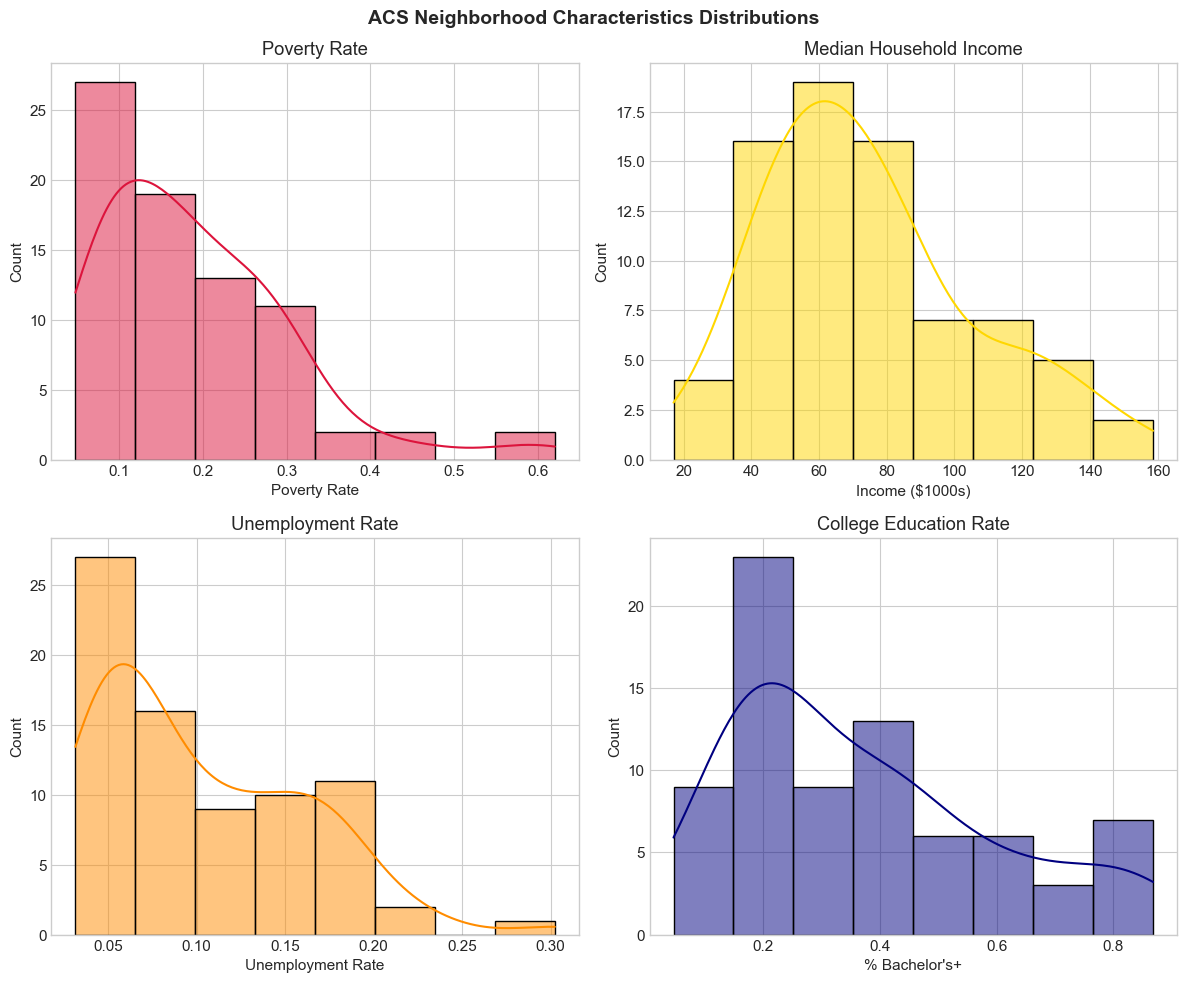

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
sns.histplot(df['acs_poverty_rate'], kde=True, ax=ax1, color='crimson', edgecolor='black')
ax1.set_xlabel('Poverty Rate')
ax1.set_title('Poverty Rate')

ax2 = axes[0, 1]
sns.histplot(df['acs_median_household_income_weighted']/1000, kde=True, ax=ax2, color='gold', edgecolor='black')
ax2.set_xlabel('Income ($1000s)')
ax2.set_title('Median Household Income')

ax3 = axes[1, 0]
sns.histplot(df['acs_unemployment_rate'], kde=True, ax=ax3, color='darkorange', edgecolor='black')
ax3.set_xlabel('Unemployment Rate')
ax3.set_title('Unemployment Rate')

ax4 = axes[1, 1]
sns.histplot(df['acs_pct_bachelor_plus'], kde=True, ax=ax4, color='navy', edgecolor='black')
ax4.set_xlabel("% Bachelor's+")
ax4.set_title('College Education Rate')

plt.suptitle('ACS Neighborhood Characteristics Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_acs_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Correlation Heatmap - All Key Variables

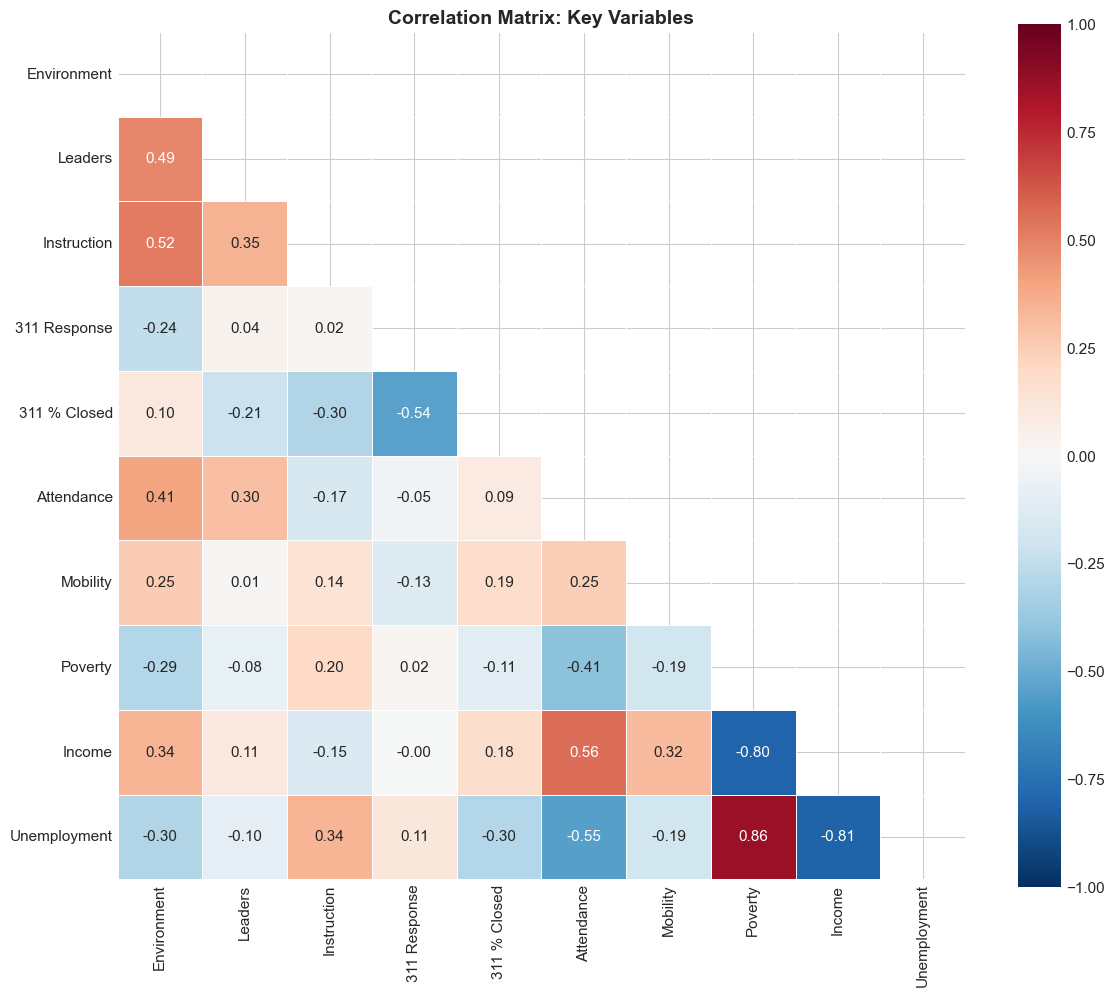

In [69]:
# Key variables for correlation analysis
key_vars = [
    'avg_environment_score', 'avg_leaders_score', 'avg_instruction_score',
    'sr_avg_median_ttc_hours', 'sr_avg_pct_closed_7d',
    'cps_student_attendance', 'cps_mobility_rate',
    'acs_poverty_rate', 'acs_median_household_income_weighted', 'acs_unemployment_rate'
]

# Short labels for display
short_labels = [
    'Environment', 'Leaders', 'Instruction',
    '311 Response', '311 % Closed',
    'Attendance', 'Mobility',
    'Poverty', 'Income', 'Unemployment'
]

corr_matrix = df[key_vars].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            xticklabels=short_labels, yticklabels=short_labels,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Key Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Correlation Heatmap - 5Essentials Components

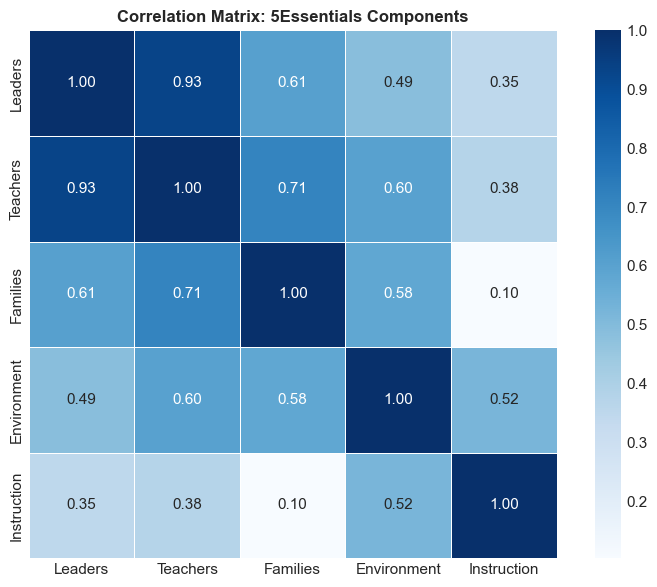

In [70]:
corr_5e = df[essentials].corr()

fig, ax = plt.subplots(figsize=(8, 6))
labels_5e = ['Leaders', 'Teachers', 'Families', 'Environment', 'Instruction']
sns.heatmap(corr_5e, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=labels_5e, yticklabels=labels_5e,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: 5Essentials Components', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_07_5essentials_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Scatterplots - Key Bivariate Relationships

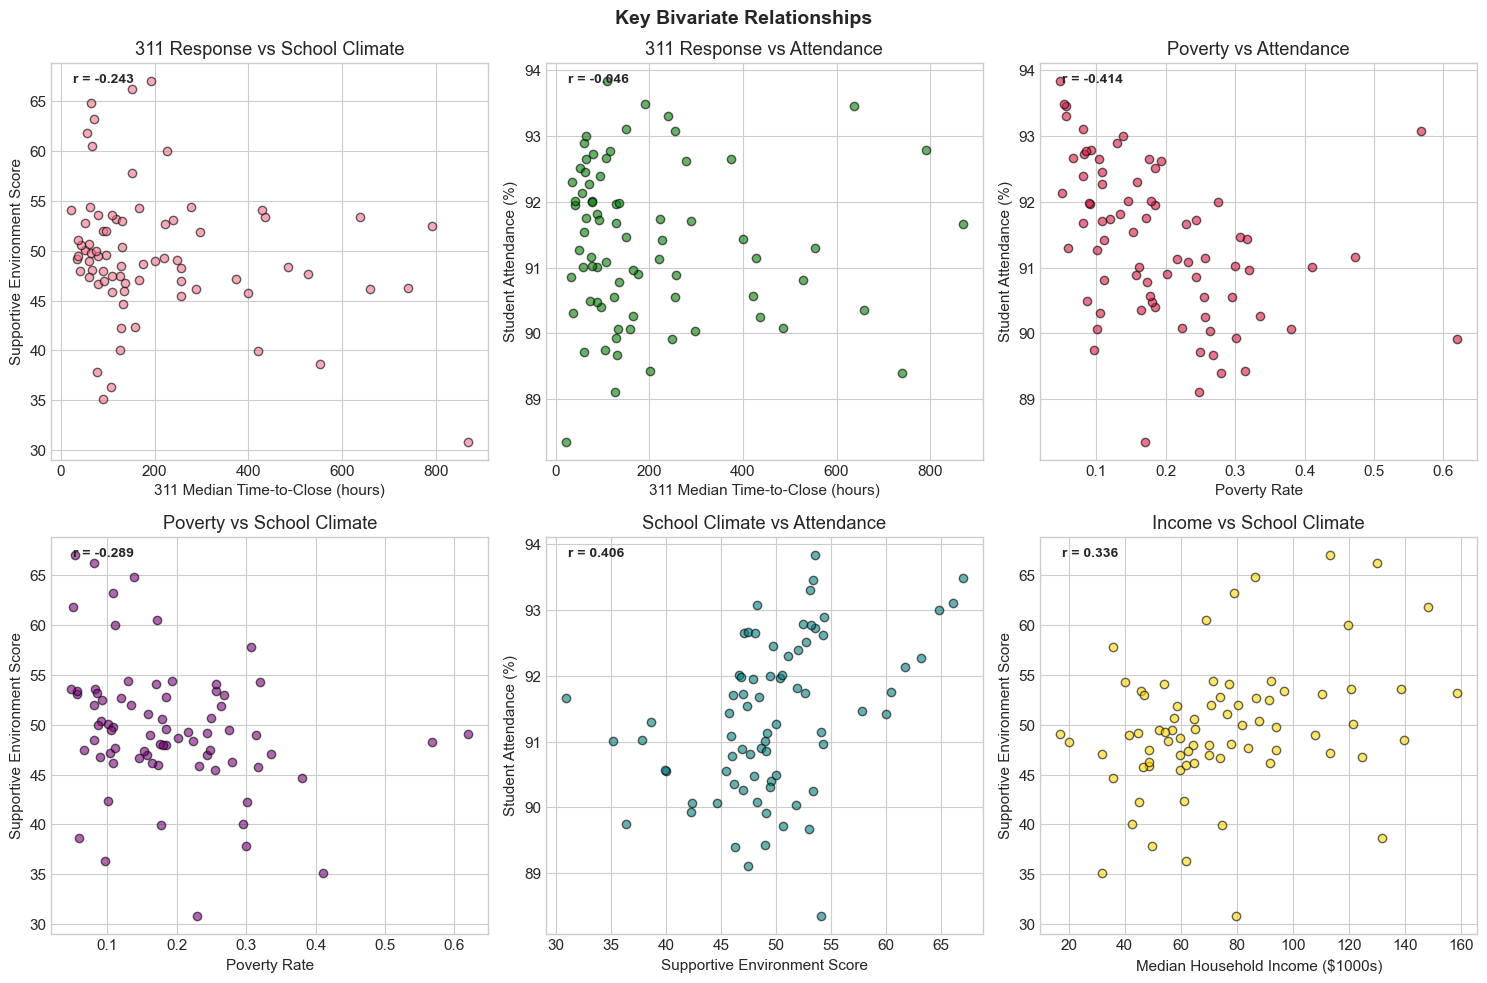

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: 311 Response Time vs School Environment
ax1 = axes[0, 0]
ax1.scatter(df['sr_avg_median_ttc_hours'], df['avg_environment_score'], alpha=0.6, edgecolor='black')
ax1.set_xlabel('311 Median Time-to-Close (hours)')
ax1.set_ylabel('Supportive Environment Score')
ax1.set_title('311 Response vs School Climate')
r = df['sr_avg_median_ttc_hours'].corr(df['avg_environment_score'])
ax1.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 2: 311 Response Time vs Student Attendance
ax2 = axes[0, 1]
ax2.scatter(df['sr_avg_median_ttc_hours'], df['cps_student_attendance'], alpha=0.6, edgecolor='black', color='green')
ax2.set_xlabel('311 Median Time-to-Close (hours)')
ax2.set_ylabel('Student Attendance (%)')
ax2.set_title('311 Response vs Attendance')
r = df['sr_avg_median_ttc_hours'].corr(df['cps_student_attendance'])
ax2.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 3: Poverty vs Student Attendance
ax3 = axes[0, 2]
ax3.scatter(df['acs_poverty_rate'], df['cps_student_attendance'], alpha=0.6, edgecolor='black', color='crimson')
ax3.set_xlabel('Poverty Rate')
ax3.set_ylabel('Student Attendance (%)')
ax3.set_title('Poverty vs Attendance')
r = df['acs_poverty_rate'].corr(df['cps_student_attendance'])
ax3.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 4: Poverty vs School Environment
ax4 = axes[1, 0]
ax4.scatter(df['acs_poverty_rate'], df['avg_environment_score'], alpha=0.6, edgecolor='black', color='purple')
ax4.set_xlabel('Poverty Rate')
ax4.set_ylabel('Supportive Environment Score')
ax4.set_title('Poverty vs School Climate')
r = df['acs_poverty_rate'].corr(df['avg_environment_score'])
ax4.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 5: School Environment vs Attendance
ax5 = axes[1, 1]
ax5.scatter(df['avg_environment_score'], df['cps_student_attendance'], alpha=0.6, edgecolor='black', color='teal')
ax5.set_xlabel('Supportive Environment Score')
ax5.set_ylabel('Student Attendance (%)')
ax5.set_title('School Climate vs Attendance')
r = df['avg_environment_score'].corr(df['cps_student_attendance'])
ax5.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

# Plot 6: Income vs School Environment
ax6 = axes[1, 2]
ax6.scatter(df['acs_median_household_income_weighted']/1000, df['avg_environment_score'], 
            alpha=0.6, edgecolor='black', color='gold')
ax6.set_xlabel('Median Household Income ($1000s)')
ax6.set_ylabel('Supportive Environment Score')
ax6.set_title('Income vs School Climate')
r = df['acs_median_household_income_weighted'].corr(df['avg_environment_score'])
ax6.annotate(f'r = {r:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, fontweight='bold')

plt.suptitle('Key Bivariate Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_08_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Regression Plots - Main Hypotheses

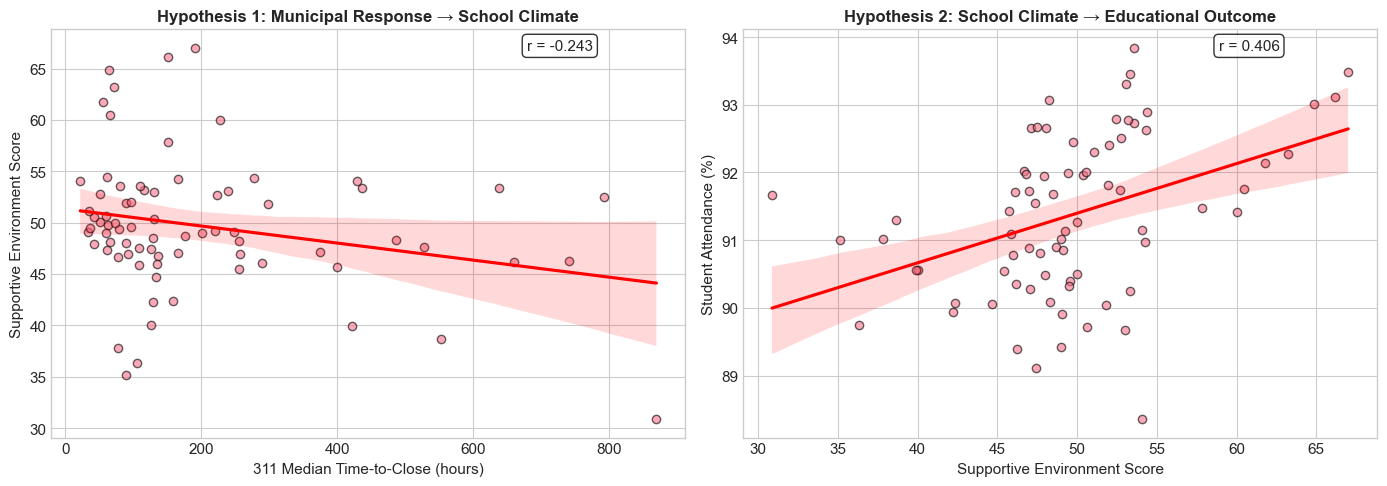

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: 311 → School Climate (with regression)
ax1 = axes[0]
sns.regplot(x='sr_avg_median_ttc_hours', y='avg_environment_score', data=df, 
            scatter_kws={'alpha':0.6, 'edgecolor':'black'}, 
            line_kws={'color':'red'}, ax=ax1)
ax1.set_xlabel('311 Median Time-to-Close (hours)', fontsize=11)
ax1.set_ylabel('Supportive Environment Score', fontsize=11)
ax1.set_title('Hypothesis 1: Municipal Response → School Climate', fontsize=12, fontweight='bold')
r = df['sr_avg_median_ttc_hours'].corr(df['avg_environment_score'])
ax1.annotate(f'r = {r:.3f}', xy=(0.75, 0.95), xycoords='axes fraction', fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: School Climate → Attendance (with regression)
ax2 = axes[1]
sns.regplot(x='avg_environment_score', y='cps_student_attendance', data=df,
            scatter_kws={'alpha':0.6, 'edgecolor':'black'},
            line_kws={'color':'red'}, ax=ax2)
ax2.set_xlabel('Supportive Environment Score', fontsize=11)
ax2.set_ylabel('Student Attendance (%)', fontsize=11)
ax2.set_title('Hypothesis 2: School Climate → Educational Outcome', fontsize=12, fontweight='bold')
r = df['avg_environment_score'].corr(df['cps_student_attendance'])
ax2.annotate(f'r = {r:.3f}', xy=(0.75, 0.95), xycoords='axes fraction', fontsize=11,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('eda_09_regression_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Boxplots by Poverty Quartiles

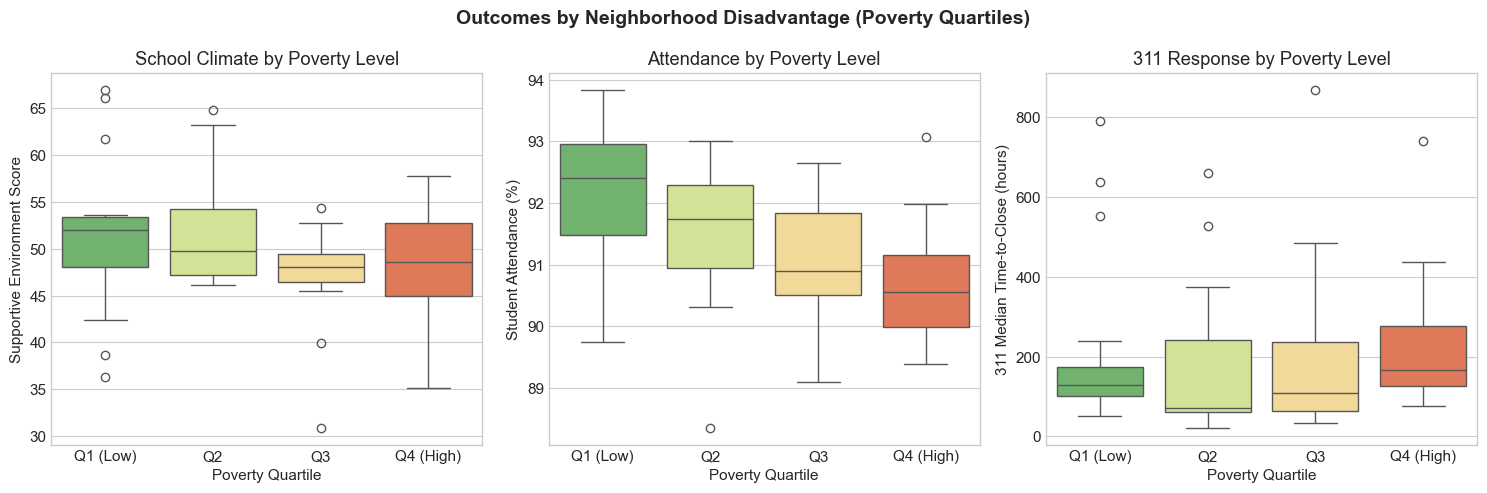

In [73]:
df['poverty_quartile'] = pd.qcut(df['acs_poverty_rate'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Box 1: Environment by Poverty Quartile
ax1 = axes[0]
sns.boxplot(x='poverty_quartile', y='avg_environment_score', data=df, ax=ax1, palette='RdYlGn_r')
ax1.set_xlabel('Poverty Quartile')
ax1.set_ylabel('Supportive Environment Score')
ax1.set_title('School Climate by Poverty Level')

# Box 2: Attendance by Poverty Quartile
ax2 = axes[1]
sns.boxplot(x='poverty_quartile', y='cps_student_attendance', data=df, ax=ax2, palette='RdYlGn_r')
ax2.set_xlabel('Poverty Quartile')
ax2.set_ylabel('Student Attendance (%)')
ax2.set_title('Attendance by Poverty Level')

# Box 3: 311 Response by Poverty Quartile
ax3 = axes[2]
sns.boxplot(x='poverty_quartile', y='sr_avg_median_ttc_hours', data=df, ax=ax3, palette='RdYlGn_r')
ax3.set_xlabel('Poverty Quartile')
ax3.set_ylabel('311 Median Time-to-Close (hours)')
ax3.set_title('311 Response by Poverty Level')

plt.suptitle('Outcomes by Neighborhood Disadvantage (Poverty Quartiles)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_10_boxplots_by_poverty.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Top/Bottom Community Areas

In [74]:
print('EXTREME COMMUNITY AREAS')

# Top 10 Slowest 311 Response
print('\n--- SLOWEST 311 Response (Top 10) ---')
slowest = df.nlargest(10, 'sr_avg_median_ttc_hours')[
    ['community_area_name', 'sr_avg_median_ttc_hours', 'avg_environment_score', 'acs_poverty_rate']
]
print(slowest.to_string(index=False))

# Top 10 Fastest 311 Response
print('\n--- FASTEST 311 Response (Top 10) ---')
fastest = df.nsmallest(10, 'sr_avg_median_ttc_hours')[
    ['community_area_name', 'sr_avg_median_ttc_hours', 'avg_environment_score', 'acs_poverty_rate']
]
print(fastest.to_string(index=False))

# Lowest School Climate
print('\n--- LOWEST School Environment Score (Bottom 10) ---')
lowest_env = df.nsmallest(10, 'avg_environment_score')[
    ['community_area_name', 'avg_environment_score', 'cps_student_attendance', 'acs_poverty_rate']
]
print(lowest_env.to_string(index=False))

# Highest Poverty
print('\n--- HIGHEST Poverty Rate (Top 10) ---')
high_poverty = df.nlargest(10, 'acs_poverty_rate')[
    ['community_area_name', 'acs_poverty_rate', 'avg_environment_score', 'cps_student_attendance']
]
print(high_poverty.to_string(index=False))

EXTREME COMMUNITY AREAS

--- SLOWEST 311 Response (Top 10) ---
community_area_name  sr_avg_median_ttc_hours  avg_environment_score  acs_poverty_rate
          HYDE PARK               869.306090              30.875000            0.2299
     LINCOLN SQUARE               791.966033              52.466667            0.0930
     AUBURN GRESHAM               740.063844              46.266667            0.2799
 WASHINGTON HEIGHTS               659.448354              46.166667            0.1641
     JEFFERSON PARK               637.922122              53.333333            0.0563
            BEVERLY               553.025050              38.666667            0.0590
            ASHBURN               527.664037              47.666667            0.1115
           ROSELAND               485.575638              48.321429            0.2234
        SOUTH SHORE               436.296620              53.333333            0.2574
       WEST PULLMAN               428.808763              54.083333          

## 15. Statistical Tests

In [75]:
# PEARSON CORRELATION TEST

pairs = [
    ('sr_avg_median_ttc_hours', 'avg_environment_score', '311 Response → Environment'),
    ('avg_environment_score', 'cps_student_attendance', 'Environment → Attendance'),
    ('acs_poverty_rate', 'cps_student_attendance', 'Poverty → Attendance'),
    ('acs_poverty_rate', 'avg_environment_score', 'Poverty → Environment'),
    ('sr_avg_median_ttc_hours', 'acs_poverty_rate', '311 Response → Poverty'),
]

results = []
for var1, var2, label in pairs:
    x = df[var1].dropna()
    y = df[var2].dropna()
    idx = x.index.intersection(y.index)
    r, p = stats.pearsonr(x[idx], y[idx])
    sig = 'Yes' if p < 0.05 else 'No'
    results.append({'Relationship': label, 'r': round(r, 3), 'p-value': round(p, 4), 'Significant': sig})
    print(f'\n{label}:')
    print(f'   r = {r:.3f}, p = {p:.4f}')
    print(f'   Result: {"Significant" if p < 0.05 else "NOT significant"}')

corr_results = pd.DataFrame(results)

print('SUMMARY TABLE')
print(corr_results.to_string(index=False))


311 Response → Environment:
   r = -0.243, p = 0.0358
   Result: Significant

Environment → Attendance:
   r = 0.406, p = 0.0003
   Result: Significant

Poverty → Attendance:
   r = -0.414, p = 0.0002
   Result: Significant

Poverty → Environment:
   r = -0.289, p = 0.0119
   Result: Significant

311 Response → Poverty:
   r = 0.018, p = 0.8799
   Result: NOT significant
SUMMARY TABLE
              Relationship      r  p-value Significant
311 Response → Environment -0.243   0.0358         Yes
  Environment → Attendance  0.406   0.0003         Yes
      Poverty → Attendance -0.414   0.0002         Yes
     Poverty → Environment -0.289   0.0119         Yes
    311 Response → Poverty  0.018   0.8799          No


In [76]:
# T-Test: Attendance by Poverty Group

median_pov = df['acs_poverty_rate'].median()
df['poverty_group'] = df['acs_poverty_rate'].apply(lambda x: 'High Poverty' if x > median_pov else 'Low Poverty')

high_pov = df[df['poverty_group'] == 'High Poverty']['cps_student_attendance'].dropna()
low_pov = df[df['poverty_group'] == 'Low Poverty']['cps_student_attendance'].dropna()

t_stat, p_value = stats.ttest_ind(high_pov, low_pov)

print(f'\nHigh Poverty: mean = {high_pov.mean():.2f}%, n = {len(high_pov)}')
print(f'Low Poverty:  mean = {low_pov.mean():.2f}%, n = {len(low_pov)}')
print(f'Difference:   {low_pov.mean() - high_pov.mean():.2f} percentage points')
print(f'\nt-statistic = {t_stat:.3f}')
print(f'p-value = {p_value:.4f}')
print(f'Result: {"Significant difference" if p_value < 0.05 else "No significant difference"}')


High Poverty: mean = 90.88%, n = 38
Low Poverty:  mean = 91.86%, n = 38
Difference:   0.97 percentage points

t-statistic = -3.936
p-value = 0.0002
Result: Significant difference


## 16. OLS Regression Models

In [77]:
# 311 Response → School Environment

X = df['sr_avg_median_ttc_hours'].dropna()
y = df['avg_environment_score'].dropna()
idx = X.index.intersection(y.index)
X_clean = X[idx]
y_clean = y[idx]

# Constant
X_const = sm.add_constant(X_clean)

# Model
model1 = sm.OLS(y_clean, X_const).fit()
print(model1.summary())

                              OLS Regression Results                             
Dep. Variable:     avg_environment_score   R-squared:                       0.059
Model:                               OLS   Adj. R-squared:                  0.046
Method:                    Least Squares   F-statistic:                     4.572
Date:                   Sat, 07 Mar 2026   Prob (F-statistic):             0.0358
Time:                           23:01:24   Log-Likelihood:                -244.52
No. Observations:                     75   AIC:                             493.0
Df Residuals:                         73   BIC:                             497.7
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [78]:
print(f'R-squared: {model1.rsquared:.4f} ({model1.rsquared*100:.1f}% variance explained)')
print(f'Coefficient: {model1.params.iloc[1]:.6f}')
print(f'P-value: {model1.pvalues.iloc[1]:.4f}')
print(f'\nCONCLUSION: 311 response does NOT significantly predict school climate.')

R-squared: 0.0589 (5.9% variance explained)
Coefficient: -0.008303
P-value: 0.0358

CONCLUSION: 311 response does NOT significantly predict school climate.


In [79]:
# School Environment → Student Attendance

X = df['avg_environment_score'].dropna()
y = df['cps_student_attendance'].dropna()
idx = X.index.intersection(y.index)
X_clean = X[idx]
y_clean = y[idx]

# Constant
X_const = sm.add_constant(X_clean)

# Model
model2 = sm.OLS(y_clean, X_const).fit()
print(model2.summary())

                              OLS Regression Results                              
Dep. Variable:     cps_student_attendance   R-squared:                       0.165
Model:                                OLS   Adj. R-squared:                  0.153
Method:                     Least Squares   F-statistic:                     14.39
Date:                    Sat, 07 Mar 2026   Prob (F-statistic):           0.000303
Time:                            23:01:24   Log-Likelihood:                -111.70
No. Observations:                      75   AIC:                             227.4
Df Residuals:                          73   BIC:                             232.0
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [80]:
print(f'R-squared: {model2.rsquared:.4f} ({model2.rsquared*100:.1f}% variance explained)')
print(f'Coefficient: {model2.params.iloc[1]:.4f}')
print(f'P-value: {model2.pvalues.iloc[1]:.4f}')
if model2.pvalues.iloc[1] < 0.05:
    print(f'\nFor every 1-point increase in environment score,')
    print(f'attendance increases by {model2.params.iloc[1]:.3f} percentage points.')
print(f'\nCONCLUSION: School climate DOES significantly predict attendance.')

R-squared: 0.1647 (16.5% variance explained)
Coefficient: 0.0733
P-value: 0.0003

For every 1-point increase in environment score,
attendance increases by 0.073 percentage points.

CONCLUSION: School climate DOES significantly predict attendance.


### Model Comparison

In [81]:
comparison = pd.DataFrame({
    'Model': ['311 → Environment', 'Environment → Attendance'],
    'R-squared': [round(model1.rsquared, 4), round(model2.rsquared, 4)],
    'Coefficient': [round(model1.params.iloc[1], 6), round(model2.params.iloc[1], 4)],
    'P-value': [round(model1.pvalues.iloc[1], 4), round(model2.pvalues.iloc[1], 4)],
    'Significant': ['No' if model1.pvalues.iloc[1] >= 0.05 else 'Yes',
                    'No' if model2.pvalues.iloc[1] >= 0.05 else 'Yes']
})
print(comparison.to_string(index=False))

                   Model  R-squared  Coefficient  P-value Significant
       311 → Environment     0.0589    -0.008303   0.0358         Yes
Environment → Attendance     0.1647     0.073300   0.0003         Yes


## 17. Bar Charts - Extreme Community Areas

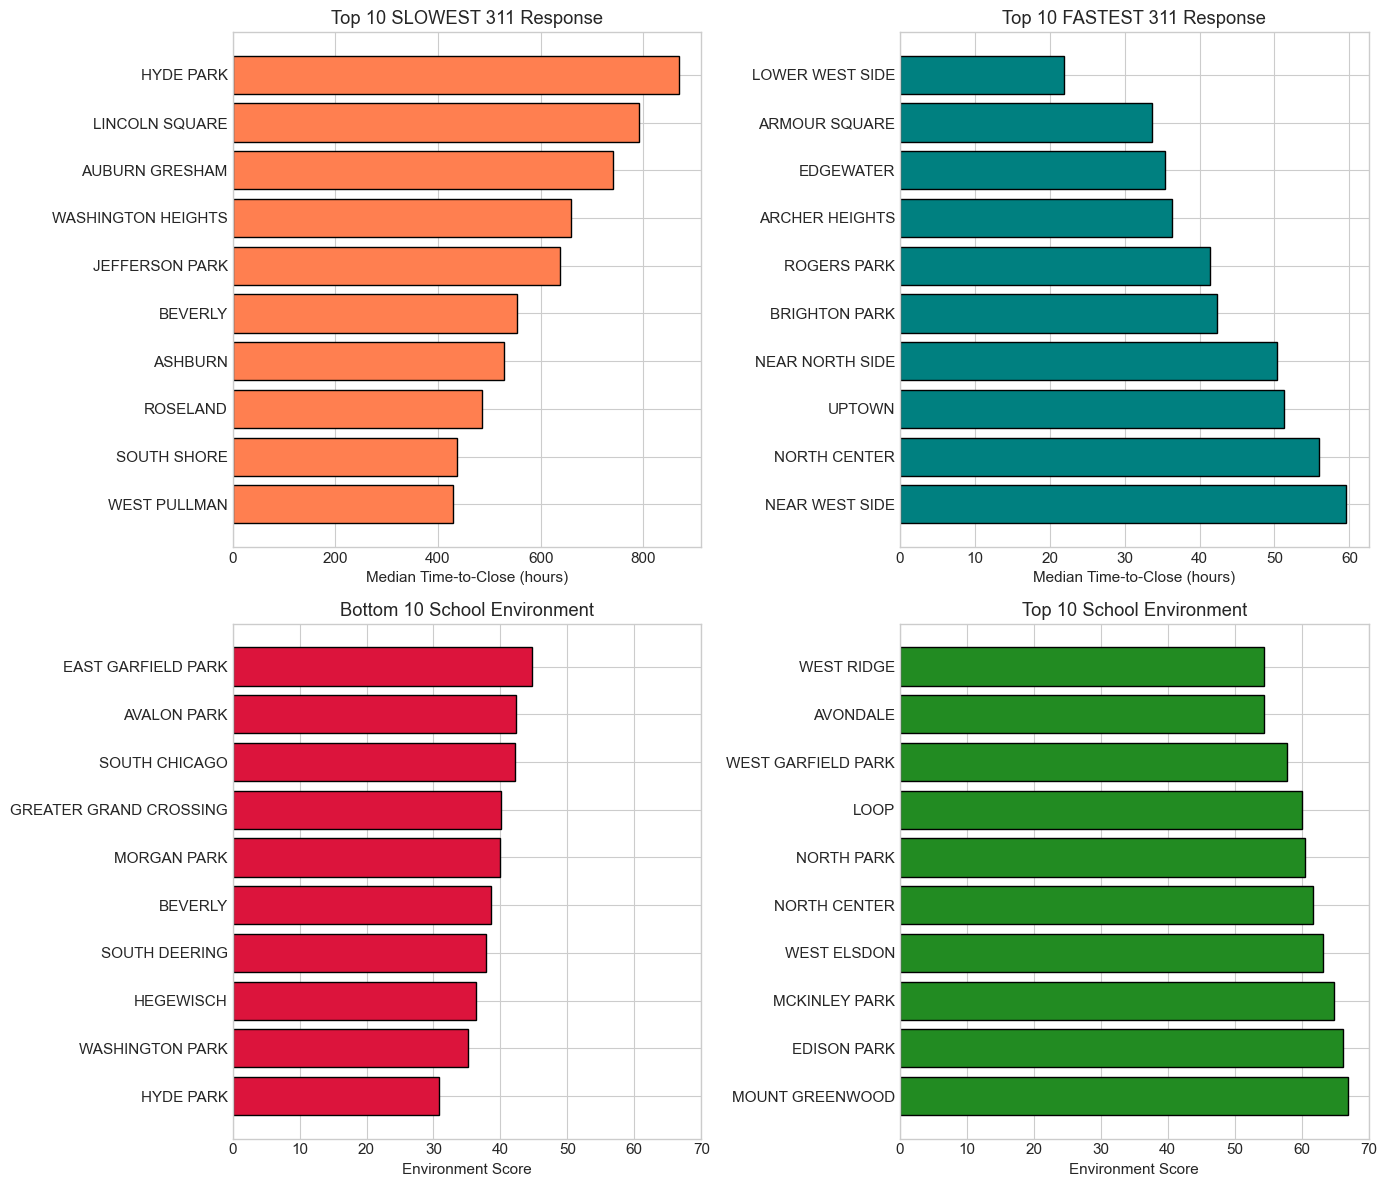

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Top 10 Slowest 311
ax1 = axes[0, 0]
top10_slow = df.nlargest(10, 'sr_avg_median_ttc_hours').sort_values('sr_avg_median_ttc_hours')
ax1.barh(top10_slow['community_area_name'], top10_slow['sr_avg_median_ttc_hours'], color='coral', edgecolor='black')
ax1.set_xlabel('Median Time-to-Close (hours)')
ax1.set_title('Top 10 SLOWEST 311 Response')

# Top 10 Fastest 311
ax2 = axes[0, 1]
top10_fast = df.nsmallest(10, 'sr_avg_median_ttc_hours').sort_values('sr_avg_median_ttc_hours', ascending=False)
ax2.barh(top10_fast['community_area_name'], top10_fast['sr_avg_median_ttc_hours'], color='teal', edgecolor='black')
ax2.set_xlabel('Median Time-to-Close (hours)')
ax2.set_title('Top 10 FASTEST 311 Response')

# Bottom 10 School Climate
ax3 = axes[1, 0]
bot10_env = df.nsmallest(10, 'avg_environment_score').sort_values('avg_environment_score')
ax3.barh(bot10_env['community_area_name'], bot10_env['avg_environment_score'], color='crimson', edgecolor='black')
ax3.set_xlabel('Environment Score')
ax3.set_title('Bottom 10 School Environment')
ax3.set_xlim(0, 70)

# Top 10 School Climate
ax4 = axes[1, 1]
top10_env = df.nlargest(10, 'avg_environment_score').sort_values('avg_environment_score', ascending=False)
ax4.barh(top10_env['community_area_name'], top10_env['avg_environment_score'], color='forestgreen', edgecolor='black')
ax4.set_xlabel('Environment Score')
ax4.set_title('Top 10 School Environment')
ax4.set_xlim(0, 70)

plt.tight_layout()
plt.savefig('eda_11_top_bottom_communities.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Pairplot - Key Variables

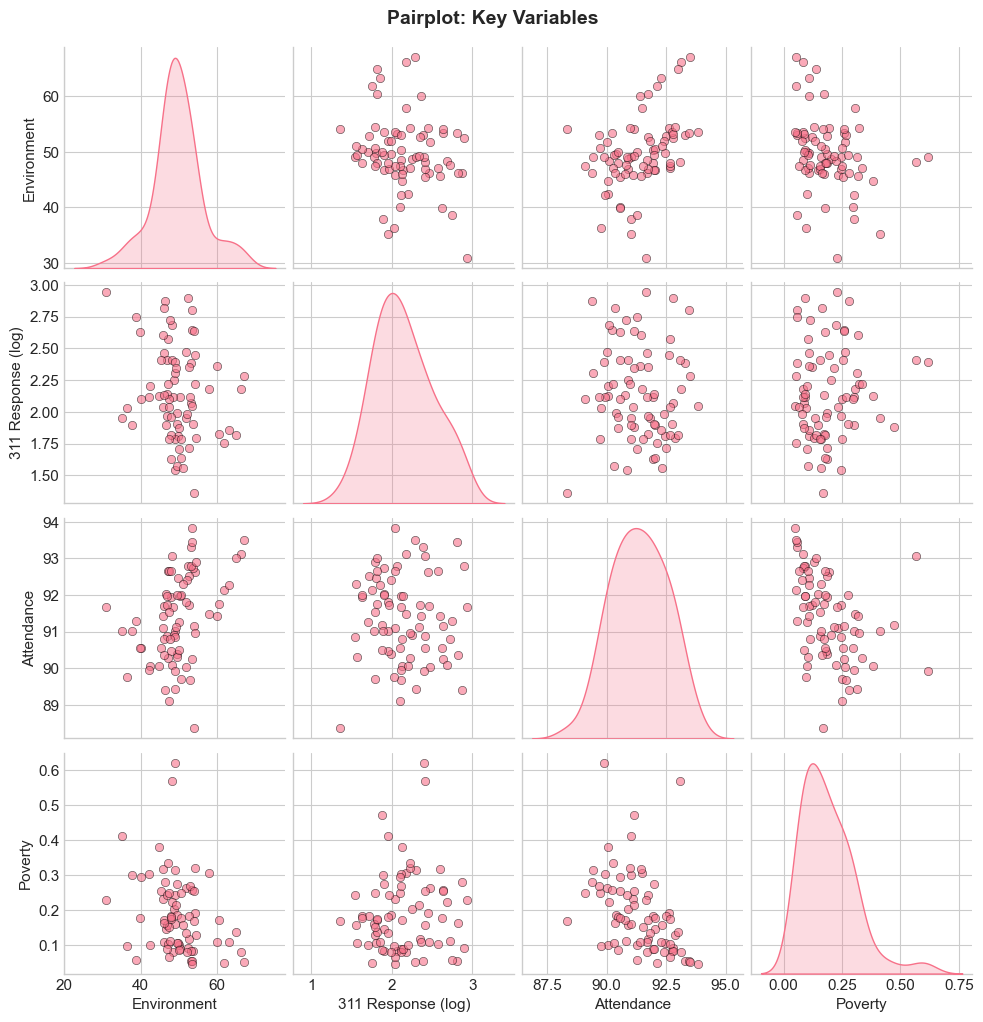

In [83]:
pairplot_vars = ['avg_environment_score', 'sr_avg_median_ttc_hours', 
                 'cps_student_attendance', 'acs_poverty_rate']

# Log transform 311 for better visualization
df_pairplot = df[pairplot_vars].copy()
df_pairplot['sr_avg_median_ttc_hours'] = np.log10(df_pairplot['sr_avg_median_ttc_hours'] + 1)
df_pairplot.columns = ['Environment', '311 Response (log)', 'Attendance', 'Poverty']

g = sns.pairplot(df_pairplot, diag_kind='kde', plot_kws={'alpha':0.6, 'edgecolor':'black'})
g.fig.suptitle('Pairplot: Key Variables', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('eda_12_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 19. Summary: Key Findings 

In [84]:
print('KEY FINDINGS SUMMARY')

# Correlations
r_311_env = df['sr_avg_median_ttc_hours'].corr(df['avg_environment_score'])
r_env_att = df['avg_environment_score'].corr(df['cps_student_attendance'])
r_pov_att = df['acs_poverty_rate'].corr(df['cps_student_attendance'])
r_pov_env = df['acs_poverty_rate'].corr(df['avg_environment_score'])
r_311_pov = df['sr_avg_median_ttc_hours'].corr(df['acs_poverty_rate'])

# Correlations result

correlations_df = pd.DataFrame({
    'Relationship': [
        'Environment ↔ Attendance',
        'Poverty ↔ Attendance',
        'Poverty ↔ Environment',
        '311 Response ↔ Environment',
        '311 Response ↔ Poverty'
    ],
    'r': [r_env_att, r_pov_att, r_pov_env, r_311_env, r_311_pov],
    'Interpretation': [
        'Moderate positive',
        'Moderate negative',
        'Weak negative',
        'Weak',
        'None'
    ]
})
correlations_df['r'] = correlations_df['r'].round(3)

print('\nCORRELATIONS:')
print(correlations_df.to_string(index=False))

# Regression result
regression_df = pd.DataFrame({
    'Model': ['311 → Environment', 'Environment → Attendance'],
    'R²': [model1.rsquared, model2.rsquared],
    'p-value': [model1.pvalues.iloc[1], model2.pvalues.iloc[1]],
    'Significant?': ['No', 'Yes']
})
regression_df['R²'] = regression_df['R²'].round(4)
regression_df['p-value'] = regression_df['p-value'].round(4)

print('\nREGRESSION RESULTS:')
print(regression_df.to_string(index=False))

print('\nLIMITATION:')
print('Cross-sectional analysis cannot establish causality.')
print('We compare areas at one time point, not changes over time.')

# Save to csv
correlations_df.to_csv('summary_correlations.csv', index=False)
regression_df.to_csv('summary_regression.csv', index=False)

KEY FINDINGS SUMMARY

CORRELATIONS:
              Relationship      r    Interpretation
  Environment ↔ Attendance  0.406 Moderate positive
      Poverty ↔ Attendance -0.414 Moderate negative
     Poverty ↔ Environment -0.289     Weak negative
311 Response ↔ Environment -0.243              Weak
    311 Response ↔ Poverty  0.018              None

REGRESSION RESULTS:
                   Model     R²  p-value Significant?
       311 → Environment 0.0589   0.0358           No
Environment → Attendance 0.1647   0.0003          Yes

LIMITATION:
Cross-sectional analysis cannot establish causality.
We compare areas at one time point, not changes over time.


## Output Files

In [85]:
# csv results
corr_results.to_csv('correlation_tests_results.csv', index=False)
comparison.to_csv('regression_comparison.csv', index=False)

figures = [
    'eda_01_5essentials_distributions.png',
    'eda_02_311_distributions.png',
    'eda_03_cps_distributions.png',
    'eda_04_acs_distributions.png',
    'eda_05_correlation_heatmap.png',
    'eda_06_5essentials_correlation.png',
    'eda_07_scatterplots.png',
    'eda_08_regression_plots.png',
    'eda_09_boxplots_by_poverty.png',
    'eda_10_top_bottom_communities.png'
]

for i, fig in enumerate(figures, 1):
    print(f'{i:2}. {fig}')
print(f'11. correlation_tests_results.csv')
print(f'12. regression_comparison.csv')

 1. eda_01_5essentials_distributions.png
 2. eda_02_311_distributions.png
 3. eda_03_cps_distributions.png
 4. eda_04_acs_distributions.png
 5. eda_05_correlation_heatmap.png
 6. eda_06_5essentials_correlation.png
 7. eda_07_scatterplots.png
 8. eda_08_regression_plots.png
 9. eda_09_boxplots_by_poverty.png
10. eda_10_top_bottom_communities.png
11. correlation_tests_results.csv
12. regression_comparison.csv
